In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# ------------ 0) Load ------------
FILE_PATH = "Diseases_Symptoms.csv"   
df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

print("\n=== INFO ===")
print(df.info())

print("\n=== Missing values per column ===")
display(df.isna().sum())

Shape: (405, 6)
Columns: ['Name', 'Symptoms', 'Treatments', 'Disease_Code', 'Contagious', 'Chronic']


,Name,Symptoms,Treatments,Disease_Code,Contagious,Chronic
0,Gestational Cholestasis,"Itchy skin, particularly on the hands and feet",NaN,D001,False,False
1,Injury to Internal Organ,"Abdominal pain, bleeding, organ dysfunction","Immediate medical attention, diagnostic tests,...",D002,False,False
2,Scabies,"Intense itching, especially at night, small bl...",Prescription medications (topical or oral scab...,D003,False,True
3,Congenital Glaucoma,"Cloudy or hazy eyes, excessive tearing, sensit...","Surgery (e.g., trabeculotomy, goniotomy) to cr...",D004,False,True
4,Avoidant/Restrictive Food Intake Disorder (ARFID),Avoidance or restriction of certain foods or e...,"Nutritional counseling, psychotherapy (such as...",D005,False,True



=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          405 non-null    object
 1   Symptoms      405 non-null    object
 2   Treatments    404 non-null    object
 3   Disease_Code  405 non-null    object
 4   Contagious    405 non-null    bool  
 5   Chronic       405 non-null    bool  
dtypes: bool(2), object(4)
memory usage: 13.6+ KB
None

=== Missing values per column ===


Name            0
Symptoms        0
Treatments      1
Disease_Code    0
Contagious      0
Chronic         0
dtype: int64

In [68]:
# ------------ 1) Basic cleaning ------------
# Trim text columns
for c in ["Name", "Symptoms", "Treatments", "Disease_Code"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Normalize Contagious/Chronic to 0/1 (handles 1/0, yes/no, true/false, y/n, strings)
def to01(x):
    if pd.isna(x): return 0
    s = str(x).strip().lower()
    return 1 if s in {"1","true","yes","y","t"} else 0

df["Contagious"] = df["Contagious"].apply(to01).astype(int)
df["Chronic"]    = df["Chronic"].apply(to01).astype(int)

# Parse Symptoms/Treatments as lists (split by comma)
def split_list(x):
    if pd.isna(x): return []
    parts = [p.strip().lower() for p in str(x).split(",")]
    return [p for p in parts if p]  # remove empty

df["Symptoms_list"]   = df["Symptoms"].apply(split_list)
df["Treatments_list"] = df["Treatments"].apply(split_list)

# Simple per-row counts
df["n_symptoms"]   = df["Symptoms_list"].apply(len)
df["n_treatments"] = df["Treatments_list"].apply(len)

In [28]:
# ------------ 2) Dataset overview ------------
print("\n=== Top diseases (by Name) ===")
display(df["Name"].value_counts().head(15))

print("\n=== Contagious/Chronic counts ===")
print("Contagious=1 rows:", int(df["Contagious"].sum()))
print("Chronic=1 rows   :", int(df["Chronic"].sum()))

print("\n=== Joint distribution (rows) ===")
display(pd.crosstab(df["Chronic"], df["Contagious"], rownames=["Chronic"], colnames=["Contagious"]))


=== Top diseases (by Name) ===


Name
Sciatica                                 3
Urinary Tract Infection (UTI)            2
Mucocele                                 2
Dermatitis due to Sun Exposure           2
Endometriosis                            2
Fibromyalgia                             2
Complex Regional Pain Syndrome (CRPS)    2
Migraine                                 2
Type 2 Diabetes                          2
Stimulant Use Disorder                   1
Fungal Infection of the Skin             1
Chancroid                                1
Gastroparesis                            1
Von Willebrand Disease                   1
Chronic Fatigue Syndrome                 1
Name: count, dtype: int64


=== Contagious/Chronic counts ===
Contagious=1 rows: 113
Chronic=1 rows   : 294

=== Joint distribution (rows) ===


Contagious,0,1
Chronic,,
0,86,25
1,206,88


In [29]:
# ------------ 3) Frequency of symptoms/treatments ------------
# Flatten lists to long form for counting
sym_long = df.explode("Symptoms_list")["Symptoms_list"]
sym_long = sym_long[sym_long.notna() & (sym_long != "")]
sym_counts = sym_long.value_counts()

treat_long = df.explode("Treatments_list")["Treatments_list"]
treat_long = treat_long[treat_long.notna() & (treat_long != "")]
treat_counts = treat_long.value_counts()

print("\n=== Top 20 Symptoms ===")
display(sym_counts.head(20))

print("\n=== Top 20 Treatments ===")
display(treat_counts.head(20))


=== Top 20 Symptoms ===


Symptoms_list
fatigue                  68
swelling                 47
fever                    36
nausea                   30
shortness of breath      25
confusion                19
vomiting                 19
redness                  18
headache                 18
abdominal pain           15
frequent urination       15
pain                     14
dizziness                14
chest pain               13
joint pain               12
weakness                 12
weight loss              12
stiffness                11
difficulty swallowing    11
tenderness               10
Name: count, dtype: int64


=== Top 20 Treatments ===


Treatments_list
physical therapy                  37
supportive care                   31
rest                              20
pain management                   20
lifestyle changes                 19
pain relievers                    16
surgery                           16
radiation therapy                 15
antibiotics                       15
support groups                    13
chemotherapy                      12
exercise                          11
warm compresses                   11
regular exercise                  10
immediate medical attention       10
medications                       10
relaxation techniques             10
targeted therapy                   9
carbonic anhydrase inhibitors)     8
surgery (in severe cases)          8
Name: count, dtype: int64

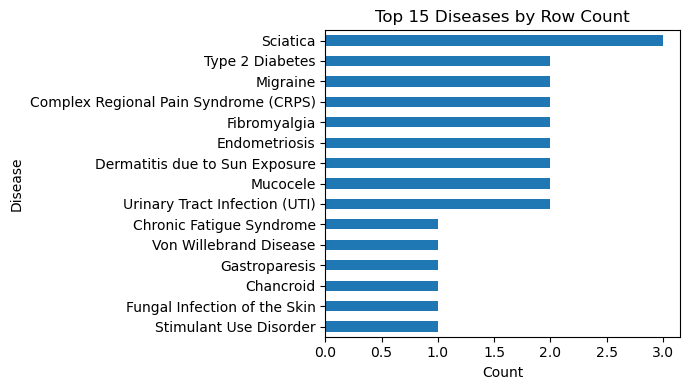

In [30]:
# ------------ 4) Plots (inline) ------------
plt.figure(figsize=(7,4))
df["Name"].value_counts().head(15).sort_values(ascending=True).plot(kind="barh")
plt.title("Top 15 Diseases by Row Count")
plt.xlabel("Count"); plt.ylabel("Disease")
plt.tight_layout(); plt.show()

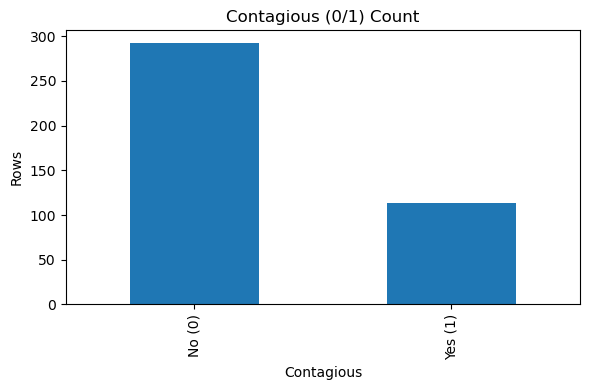

In [31]:
plt.figure(figsize=(6,4))
df["Contagious"].value_counts().sort_index().plot(kind="bar")
plt.title("Contagious (0/1) Count")
plt.xticks([0,1], ["No (0)","Yes (1)"])
plt.ylabel("Rows")
plt.tight_layout(); plt.show()

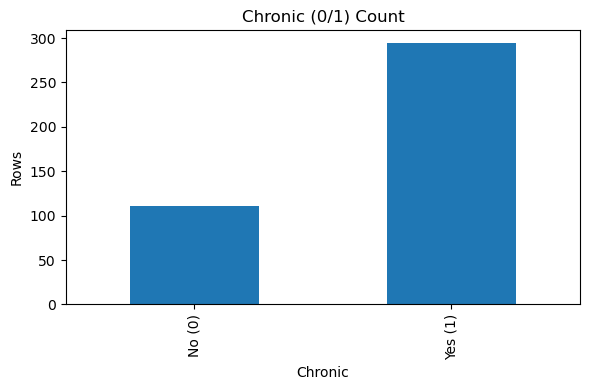

In [32]:
plt.figure(figsize=(6,4))
df["Chronic"].value_counts().sort_index().plot(kind="bar")
plt.title("Chronic (0/1) Count")
plt.xticks([0,1], ["No (0)","Yes (1)"])
plt.ylabel("Rows")
plt.tight_layout(); plt.show()

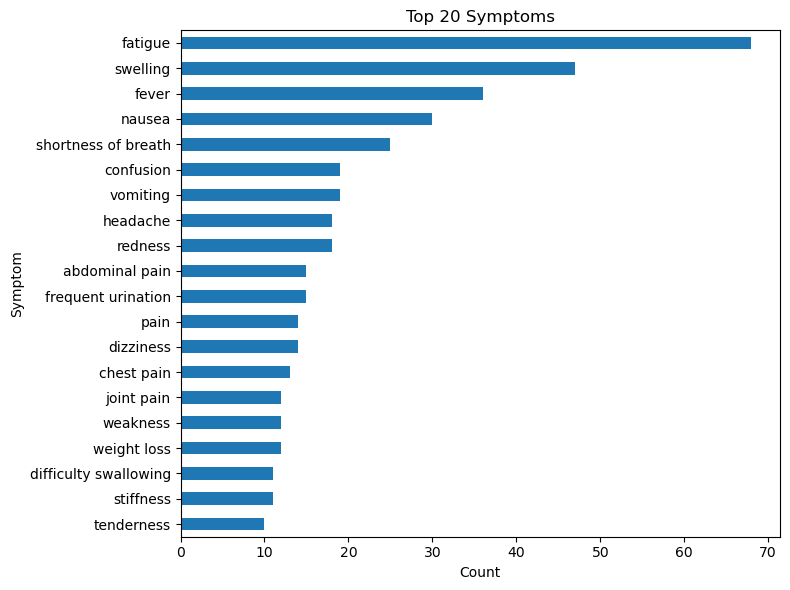

In [33]:

# Top 20 symptoms
topk = 20
plt.figure(figsize=(8,6))
sym_counts.head(topk).sort_values(ascending=True).plot(kind="barh")
plt.title(f"Top {topk} Symptoms")
plt.xlabel("Count"); plt.ylabel("Symptom")
plt.tight_layout(); plt.show()


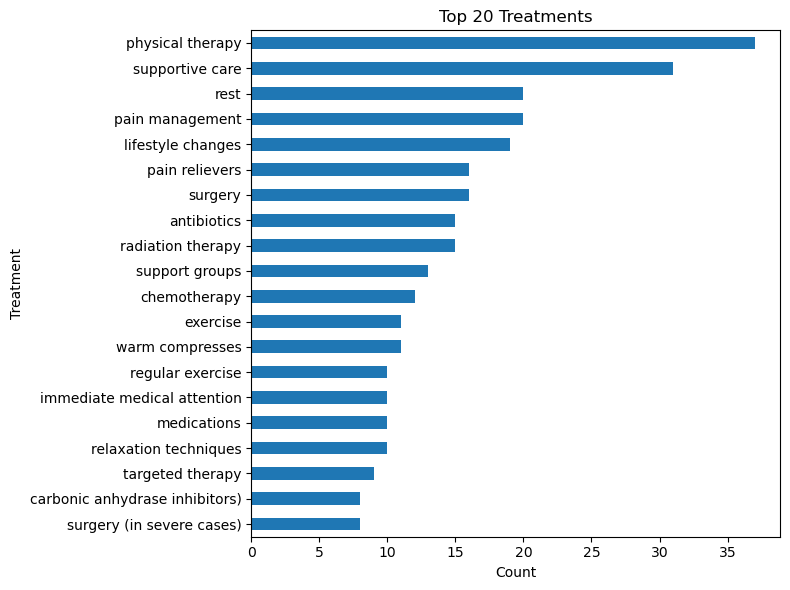

In [34]:
# Top 20 treatments
plt.figure(figsize=(8,6))
treat_counts.head(topk).sort_values(ascending=True).plot(kind="barh")
plt.title(f"Top {topk} Treatments")
plt.xlabel("Count"); plt.ylabel("Treatment")
plt.tight_layout(); plt.show()

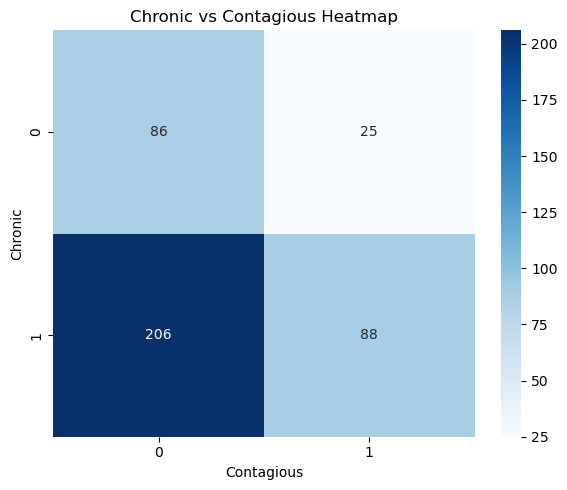

In [64]:
# heatmap to visualize the relationship between chronic and contagious status.
plt.figure(figsize=(6,5))
sns.heatmap(pd.crosstab(df["Chronic"], df["Contagious"]), 
            annot=True, fmt='d', cmap='Blues')
plt.title("Chronic vs Contagious Heatmap")
plt.tight_layout(); plt.show()

In [66]:
# Create a DataFrame with symptom-treatment pairs Analyzes which symptoms are commonly treated with which treatments.
symptom_treatment_pairs = []
for _, row in df.iterrows():
    for symptom in row['Symptoms_list']:
        for treatment in row['Treatments_list']:
            symptom_treatment_pairs.append((symptom, treatment))

pairs_df = pd.DataFrame(symptom_treatment_pairs, columns=['Symptom', 'Treatment'])
pair_counts = pairs_df.groupby(['Symptom', 'Treatment']).size().reset_index(name='Count')

# Top 10 most common symptom-treatment pairs
print("Top 10 Symptom-Treatment pairs:")
display(pair_counts.sort_values('Count', ascending=False).head(10))

Top 10 Symptom-Treatment pairs:


,Symptom,Treatment,Count
7593,swelling,physical therapy,17
2948,fatigue,supportive care,12
7588,swelling,pain management,11
3155,fever,supportive care,10
7363,stiffness,physical therapy,10
1245,confusion,supportive care,7
3628,headache,supportive care,7
3050,fever,antibiotics,7
4757,limited range of motion,physical therapy,6
4646,joint pain,physical therapy,6


In [58]:
chronic_stats = df.groupby('Chronic').agg({
    'n_symptoms': 'mean',
    'n_treatments': 'mean'
}).round(2)

print("Average symptoms/treatments by Chronic status:")
display(chronic_stats)

Average symptoms/treatments by Chronic status:


,n_symptoms,n_treatments
Chronic,,
0,3.72,3.81
1,4.38,5.41


In [60]:
# Save the cleaned DataFrame
df.to_csv("cleaned_diseases_symptoms.csv", index=False)
print("Cleaned dataset saved as 'cleaned_diseases_symptoms.csv'")

Cleaned dataset saved as 'cleaned_diseases_symptoms.csv'


In [62]:
print("\n=== FINAL SUMMARY ===")
print(f"Total diseases: {len(df)}")
print(f"Contagious diseases: {df['Contagious'].sum()} ({df['Contagious'].mean()*100:.1f}%)")
print(f"Chronic diseases: {df['Chronic'].sum()} ({df['Chronic'].mean()*100:.1f}%)")
print(f"Average symptoms per disease: {df['n_symptoms'].mean():.2f}")
print(f"Average treatments per disease: {df['n_treatments'].mean():.2f}")
print(f"Unique symptoms: {len(sym_counts)}")
print(f"Unique treatments: {len(treat_counts)}")


=== FINAL SUMMARY ===
Total diseases: 405
Contagious diseases: 113 (27.9%)
Chronic diseases: 294 (72.6%)
Average symptoms per disease: 4.20
Average treatments per disease: 4.98
Unique symptoms: 939
Unique treatments: 1300
